In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


In [113]:
# AND gate inputs and outputs
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

np.random.seed(0)
weights = np.random.uniform(0.2, 0.8, 2)
bias = 0.2

def perceptron(x, weights, bias, threshold):
    return 1 if np.dot(x, weights) + bias >= threshold else 0

errors = []
for xi, target in zip(X, y):
    output = perceptron(xi, weights, bias, 1)
    error = target - output
    errors.append(error)

print("AND gate weights:", weights)
print("Errors:", errors)

AND gate weights: [0.5292881  0.62911362]
Errors: [np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [114]:
# OR gate inputs and outputs
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

# Random weights between 0.4 and 0.7
np.random.seed(1)
weights = np.random.uniform(0.4, 0.7, 2)
bias = 0.2

def perceptron(x, weights, bias, threshold):
    return 1 if np.dot(x, weights) + bias >= threshold else 0

errors = []
for xi, target in zip(X, y):
    output = perceptron(xi, weights, bias, 0.4)
    error = target - output
    errors.append(error)

print("OR gate weights:", weights)
print("Errors:", errors)

OR gate weights: [0.5251066  0.61609735]
Errors: [np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


AND Gate Table:
   Input1  Input2  Target  Predicted  Error
0       0       0       0          0      0
1       0       1       0          0      0
2       1       0       0          0      0
3       1       1       1          1      0


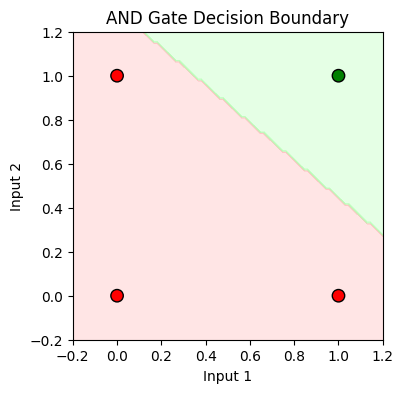


OR Gate Table:
   Input1  Input2  Target  Predicted  Error
0       0       0       0          0      0
1       0       1       1          1      0
2       1       0       1          1      0
3       1       1       1          1      0


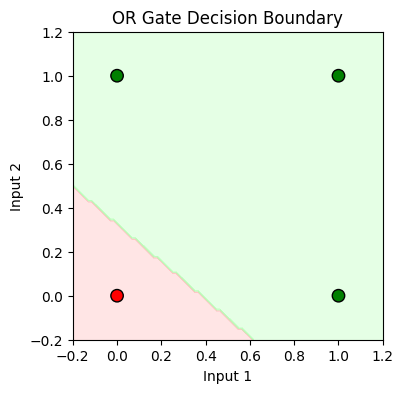


NOT Gate Table:
   Input  Target  Predicted  Error
0      0       1          1      0
1      1       0          0      0


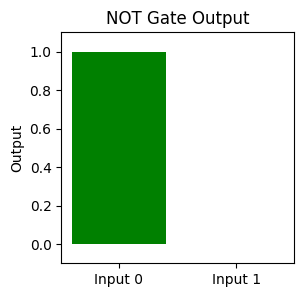

In [115]:



# AND gate table and decision boundary
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
outputs_and = [perceptron(xi, weights, bias, 1) for xi in X_and]
errors_and = y_and - np.array(outputs_and)
df_and = pd.DataFrame({"Input1": X_and[:,0], "Input2": X_and[:,1], "Target": y_and, "Predicted": outputs_and, "Error": errors_and})
print("AND Gate Table:")
print(df_and)

plt.figure(figsize=(4,4))
plt.title("AND Gate Decision Boundary")
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = np.array([perceptron([x, y], weights, bias, 1) for x, y in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']))
plt.scatter(X_and[:,0], X_and[:,1], c=y_and, cmap=ListedColormap(['red', 'green']), edgecolor='k', s=80)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

# OR gate table and decision boundary
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])
outputs_or = [perceptron(xi, weights, bias, 0.4) for xi in X_or]
errors_or = y_or - np.array(outputs_or)
df_or = pd.DataFrame({"Input1": X_or[:,0], "Input2": X_or[:,1], "Target": y_or, "Predicted": outputs_or, "Error": errors_or})
print("\nOR Gate Table:")
print(df_or)

plt.figure(figsize=(4,4))
plt.title("OR Gate Decision Boundary")
Z = np.array([perceptron([x, y], weights, bias, 0.4) for x, y in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']))
plt.scatter(X_or[:,0], X_or[:,1], c=y_or, cmap=ListedColormap(['red', 'green']), edgecolor='k', s=80)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

# NOT gate table and bar plot
X_not = np.array([0,1])
y_not = np.array([1,0])
outputs_not = [1 if (-1*x + 0.5) >= 0 else 0 for x in X_not]
errors_not = y_not - np.array(outputs_not)
df_not = pd.DataFrame({"Input": X_not, "Target": y_not, "Predicted": outputs_not, "Error": errors_not})
print("\nNOT Gate Table:")
print(df_not)

plt.figure(figsize=(3,3))
plt.bar(["Input 0","Input 1"], outputs_not, color=['green','red'])
plt.title("NOT Gate Output")
plt.ylabel("Output")
plt.ylim(-0.1,1.1)
plt.show()



### 3. NOT Gate Perceptron

**Neural Network Structure for NOT Operation:**

- The NOT gate takes a single binary input X (0 or 1) and outputs the opposite value.
- The perceptron has one input neuron and one output neuron.
- The output neuron applies a weighted sum and a bias, then passes the result through an activation function (step function).

**Weights and Biases:**

- To achieve NOT logic, set the weight to -1 and the bias to 0.5.
- The perceptron computes: output = 1 if (-1 * X + 0.5) ≥ 0 else 0.
- This means:
    - If X = 0: (-1*0 + 0.5) = 0.5 → output = 1
    - If X = 1: (-1*1 + 0.5) = -0.5 → output = 0
- These values ensure the perceptron replicates the NOT gate.

**Why these values?**

- The negative weight inverts the input.
- The bias shifts the threshold so that only X=0 produces output 1.


### 3.2 Training a Neural Network for Logic Gates

1. **Initialize weights and bias** (randomly or with chosen values).
2. **Feed input-output pairs** (training data) to the network.
3. **Calculate output** using the current weights and bias.
4. **Compute error**: error = target - output.
5. **Update weights and bias** using a learning rule (e.g., perceptron learning rule):
    - weights += learning_rate * error * input
    - bias += learning_rate * error
6. **Repeat** for all training samples and multiple epochs until errors are minimized.





### Interpretation

- After training, check the perceptron's predictions for all possible inputs.
- If the output matches the expected logic gate outputs, training is successful.
- Errors close to zero indicate good learning.

Program 2

In [116]:
#laoding data
df = pd.read_csv('set2.csv')
X = df[['VisITedResources', 'Discussion']].values
y = df['Class'].values

In [117]:
#1 mean values
mean_L = X[y == 'L'].mean(axis=0)
mean_H = X[y == 'H'].mean(axis=0)
print(mean_L)
print(mean_H)

[18.32283465 30.83464567]
[78.74647887 53.66197183]


In [118]:
#2 cov matrix

def cov_matrix(X):
    m = X.mean(axis=0)
    return ((X - m).T @ (X - m)) / (X.shape[0] - 1)

S1 = cov_matrix(X[y == 'L'])
S2 = cov_matrix(X[y == 'H'])


print(S1)
print(S2)

[[ 3.68140982e+02 -6.52543432e-01]
 [-6.52543432e-01  6.61012123e+02]]
[[374.67285985   2.33922685]
 [  2.33922685 739.61542303]]


In [119]:
# 3. Compute within-class scatter matrix
SW = S1 + S2  # SW = S1 + S2, where S1 and S2 are covariance matrices for classes L and H
mean_total = X.mean(axis=0)  # Mean of all samples

In [120]:

# 4. Compute between-class scatter matrix
SB = np.outer(mean_L - mean_H, mean_L - mean_H)  # SB measures the distance between class means
SW_inv = np.linalg.inv(SW)  # Inverse of within-class scatter

In [ ]:
# 5. LDA projection
W_lda = SW_inv @ (mean_L - mean_H) 
X_lda = X @ W_lda  

In [128]:
# 6. Calculate eigenvector W using the formula: (covariance_matrix - lambda*I)W = 0

cov = ((X_std - X_std.mean(axis=0)).T @ (X_std - X_std.mean(axis=0))) / (X_std.shape[0] - 1)
eigvals, eigvecs = np.linalg.eig(cov) 
print('Eigenvalues:', eigvals)
print('Eigenvectors (columns):\n', eigvecs)

Eigenvalues: [0.66734338 1.34011931]
Eigenvectors (columns):
 [[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


In [ ]:
# 7. Multiply every two-dimensional input sample with the largest eigenvector (first principal component)
largest_eigenvector = W_pca[:,0]  
X_proj = X_std @ largest_eigenvector  
print(X_proj)

[-1.65959019 -0.8119381  -1.3753155  -1.25553809 -0.24443967 -1.69808712
 -1.18072896 -1.69913808 -1.40252895 -0.05458245 -1.08448665  0.41736475
  0.58081108 -0.19938859  0.29443447 -0.69592185 -1.25553809 -0.98298954
  0.05609621 -0.54359339 -0.67614791  1.05599395 -1.25553809 -1.25553809
 -1.25553809 -1.74725923 -0.19938859 -1.15666838 -1.15666838 -0.98509146
 -0.73546973 -1.33681857 -0.94178242 -1.36884414 -0.86058474 -0.82900185
  0.20781639  0.01007697  0.20781639  0.89727694 -1.62327799 -0.73870541
 -0.04924485 -0.65960965 -0.540966   -0.73870541 -1.77289625 -0.15668783
  0.44886484 -0.07645831 -0.02142312 -1.46989857 -1.80658106 -1.27531203
 -1.60508048 -1.40305443 -1.89477557 -1.86161624 -1.70447567  0.9453153
 -1.5916951   0.72780194 -1.14809511 -0.52329397 -0.35119157  1.01268492
 -1.29508597 -0.65374657  0.99291097  0.7705855  -0.26623273 -0.04871937
 -1.77823384 -1.78733259 -1.70289923 -1.604555   -1.47252597 -1.28335982
 -1.73816048 -1.60402953 -1.15990406 -1.40629011 -0.

LDA Projection Vector (W_lda): [-0.08130748 -0.01620001]
Projected Data (X_lda): [-8.45105918 -6.66352429 -5.6691753  -7.63859921 -1.78323119 -7.93019947
 -6.90652451 -8.61367413 -7.39406197 -6.09621639 -8.20867378 -5.85352358
 -1.78569044 -7.62547327 -5.93452365 -7.88436609 -7.63859921 -6.09344973
 -7.59368805 -7.85227347 -7.80305861 -2.6333171  -7.63859921 -7.63859921
 -7.63859921 -7.9625995  -7.62547327 -7.23206183 -7.23206183 -7.46039906
 -8.04698104 -6.190035   -8.04636623 -7.84981421 -6.35418699 -8.17688856
 -4.76258931 -5.57566409 -4.76258931 -3.62551425 -7.19812476 -6.95666158
 -5.81958652 -6.63143167 -6.14358681 -6.95666158 -8.66227418 -5.41243432
 -4.53548171 -7.54447319 -6.89370597 -6.48255748 -8.20652193 -7.71990669
 -8.14202928 -7.7357993  -8.05979958 -8.85728916 -8.890304   -1.13584544
 -9.02082634 -2.03022769 -8.04575142 -7.42922866 -7.31582856 -2.04734992
 -7.80121417 -6.01306447 -2.1286574  -2.95793219 -6.37223145 -5.47784919
 -8.93890404 -8.46695179 -7.86509201 -7.800

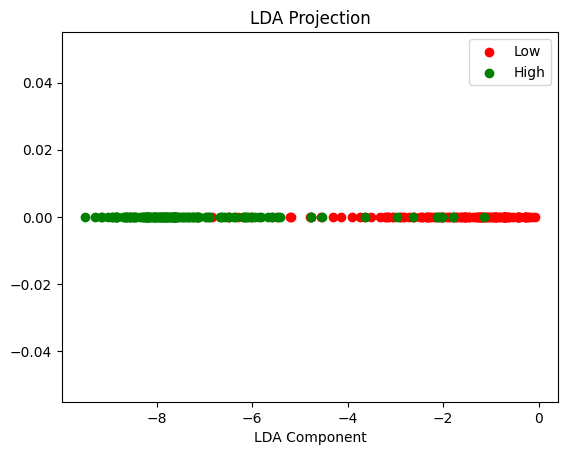

In [124]:

# Display results
print("LDA Projection Vector (W_lda):", W_lda)  
print("Projected Data (X_lda):", X_lda) 
print("Within-class Scatter Matrix (SW):", SW)
print("Between-class Scatter Matrix (SB):", SB)

# Visualize LDA projection
plt.scatter(X_lda[y == 'L'], np.zeros_like(X_lda[y == 'L']), label='Low', color='red')  # Low class
plt.scatter(X_lda[y == 'H'], np.zeros_like(X_lda[y == 'H']), label='High', color='green')  # High class
plt.legend()
plt.title('LDA Projection')
plt.xlabel('LDA Component')
plt.show()

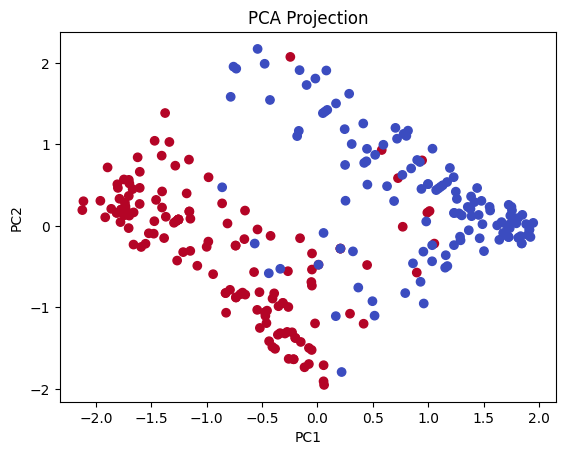

In [ ]:

#09 Standardize features for PCA
X_full = df[['VisITedResources', 'Discussion']].values
X_std = (X_full - X_full.mean(axis=0)) / X_full.std(axis=0)  

# 10. Compute covariance matrix manually
cov = ((X_std - X_std.mean(axis=0)).T @ (X_std - X_std.mean(axis=0))) / (X_std.shape[0] - 1)

#11 Calculate eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(cov)  

#12 Sort eigenvalues and eigenvectors
idx = eigvals.argsort()[::-1] 
eigvals = eigvals[idx] 
eigvecs = eigvecs[:, idx] 

#13 Select top 2 eigenvectors for PCA
W_pca = eigvecs[:, :2]  

#14 Transform data to new PCA space
X_pca = X_std @ W_pca  

#15 Visualize PCA projection
plt.scatter(X_pca[:,0], X_pca[:,1], c=(y == 'H'), cmap='coolwarm') 
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Interpretation of PCA Results

PCA reduces the dimensionality of the data by projecting it onto the directions (principal components) that capture the most variance.

In the scatter plot, each point represents a student, positioned according to their values on the first two principal components (PC1 and PC2).

If students from different classes (Low and High performance) are separated in this space, it means the selected features (VisITedResources, Discussion) help distinguish between performance levels.

A clear separation indicates that these features are informative for classification. Overlapping points suggest the features alone may not be sufficient for perfect separation.